1. Import Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

2: Load Dataset from Kaggle (Using Kaggle API)

Setup Kaggle API

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


Download Dataset

In [3]:
!kaggle datasets download -d kritikseth/fruit-and-vegetable-image-recognition

Dataset URL: https://www.kaggle.com/datasets/kritikseth/fruit-and-vegetable-image-recognition
License(s): CC0-1.0
100% 1.98G/1.98G [00:08<00:00, 256MB/s]



Unzip Dataset

In [4]:
!unzip -q fruit-and-vegetable-image-recognition.zip -d data

3: Understand Dataset Structure

In [5]:
data_dir = "/content/data"

print(os.listdir(data_dir))

['train', 'validation', 'test']


In [7]:
train_path = os.path.join(data_dir, "validation")
print(os.listdir(train_path))

['sweetpotato', 'capsicum', 'lettuce', 'spinach', 'mango', 'cucumber', 'potato', 'pear', 'soy beans', 'ginger', 'tomato', 'corn', 'cauliflower', 'orange', 'beetroot', 'carrot', 'turnip', 'lemon', 'jalepeno', 'kiwi', 'sweetcorn', 'eggplant', 'paprika', 'raddish', 'grapes', 'onion', 'pineapple', 'banana', 'peas', 'pomegranate', 'bell pepper', 'watermelon', 'garlic', 'apple', 'cabbage', 'chilli pepper']


In [10]:
import os
import shutil


data_dir = "/content/data"

splits = ['train', 'validation', 'test']

#  Fruit classes
fruit_classes = {
    'banana', 'apple', 'pear', 'grapes', 'orange', 'kiwi',
    'watermelon', 'pomegranate', 'pineapple', 'mango'
}

#  Vegetable classes
vegetable_classes = {
    'cucumber', 'carrot', 'capsicum', 'onion', 'potato', 'lemon',
    'tomato', 'radish', 'beetroot', 'cabbage', 'lettuce', 'spinach',
    'soybean', 'cauliflower', 'bell pepper', 'chilli pepper',
    'pepper', 'turnip', 'corn', 'sweetcorn', 'sweet potato',
    'paprika', 'jalapeno', 'ginger', 'garlic', 'peas', 'eggplant'
}

#  Fix dataset naming issues
name_corrections = {
    'raddish': 'radish',
    'jalepeno': 'jalapeno',
    'soy beans': 'soybean',
    'sweetpotato': 'sweet potato'
}

for split in splits:
    print(f"\n📂 Processing {split}...")

    split_path = os.path.join(data_dir, split)

    fruit_path = os.path.join(split_path, "fruit")
    veg_path = os.path.join(split_path, "vegetable")

    os.makedirs(fruit_path, exist_ok=True)
    os.makedirs(veg_path, exist_ok=True)

    for class_name in os.listdir(split_path):

        class_path = os.path.join(split_path, class_name)

        # Skip non-folders
        if not os.path.isdir(class_path):
            continue

        # Skip already processed folders
        if class_name in ['fruit', 'vegetable']:
            continue

        #  Normalize name
        clean_name = class_name.lower().strip()

        #  Apply corrections
        if clean_name in name_corrections:
            clean_name = name_corrections[clean_name]

        #  Assign label
        if clean_name in fruit_classes:
            target_dir = fruit_path
            label = "Fruit"
        elif clean_name in vegetable_classes:
            target_dir = veg_path
            label = "Vegetable"
        else:
            print(f" Unknown class skipped: {class_name}")
            continue

        moved_files = 0

        #  Move files safely
        for file in os.listdir(class_path):
            src = os.path.join(class_path, file)

            if os.path.isfile(src):  # only move files
                dst = os.path.join(target_dir, file)

                try:
                    shutil.move(src, dst)
                    moved_files += 1
                except Exception as e:
                    print(f"⚠️ Error moving {file}: {e}")

        print(f"✔ {class_name} → {label} ({moved_files} files moved)")

        #  Remove folder safely
        try:
            shutil.rmtree(class_path)
        except Exception as e:
            print(f"⚠️ Could not delete {class_name}: {e}")

print("\n Labeling & restructuring completed!")


📂 Processing train...
✔ capsicum → Vegetable (58 files moved)
✔ lettuce → Vegetable (97 files moved)
✔ spinach → Vegetable (97 files moved)
✔ mango → Fruit (86 files moved)
✔ cucumber → Vegetable (94 files moved)
✔ potato → Vegetable (77 files moved)
✔ pear → Fruit (89 files moved)
✔ soy beans → Vegetable (97 files moved)
✔ ginger → Vegetable (68 files moved)
✔ tomato → Vegetable (92 files moved)
✔ corn → Vegetable (87 files moved)
✔ cauliflower → Vegetable (79 files moved)
✔ orange → Fruit (69 files moved)
✔ beetroot → Vegetable (88 files moved)
✔ carrot → Vegetable (82 files moved)
✔ turnip → Vegetable (98 files moved)
✔ lemon → Vegetable (82 files moved)
✔ jalepeno → Vegetable (88 files moved)
✔ kiwi → Fruit (88 files moved)
✔ sweetcorn → Vegetable (91 files moved)
✔ eggplant → Vegetable (84 files moved)
✔ paprika → Vegetable (83 files moved)
✔ raddish → Vegetable (81 files moved)
✔ grapes → Fruit (100 files moved)
✔ onion → Vegetable (94 files moved)
✔ pineapple → Fruit (99 files 

4: Data Preprocessing & Loading

In [11]:
# Image size and batch size
img_size = (224, 224)
batch_size = 32

train_dir = os.path.join(data_dir, "train")
val_dir = os.path.join(data_dir, "validation")
test_dir = os.path.join(data_dir, "test")

# Data generators
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

Found 433 images belonging to 2 classes.
Found 34 images belonging to 2 classes.
Found 41 images belonging to 2 classes.


5: Build CNN Model

In [12]:
model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6: Compile Model

In [13]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

7: Train Model

In [14]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=4
)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/4
14/14 ━━━━━━━━━━━━━━━━━━━━ 50s 3s/step - accuracy: 0.5612 - loss: 1.0612 - val_accuracy: 0.6765 - val_loss: 0.6316
Epoch 2/4
14/14 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.6443 - loss: 0.6286 - val_accuracy: 0.6176 - val_loss: 0.6183
Epoch 3/4
14/14 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.6605 - loss: 0.6395 - val_accuracy: 0.6765 - val_loss: 0.5427
Epoch 4/4
14/14 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.6952 - loss: 0.5957 - val_accuracy: 0.7059 - val_loss: 0.5236


8: Evaluate Model

In [15]:
test_loss, test_acc = model.evaluate(test_generator)

print("Test Accuracy:", test_acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 188ms/step - accuracy: 0.7317 - loss: 0.5056
Test Accuracy: 0.7317073345184326


9: Plot Results

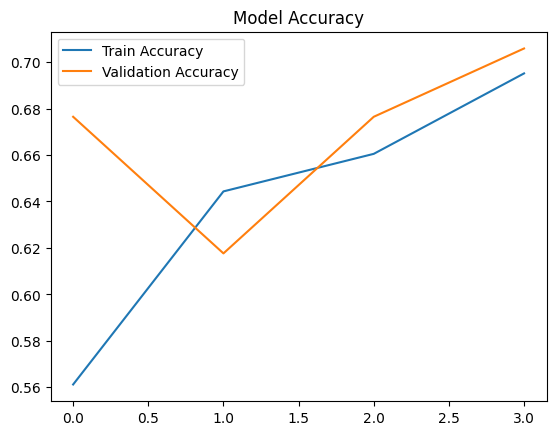

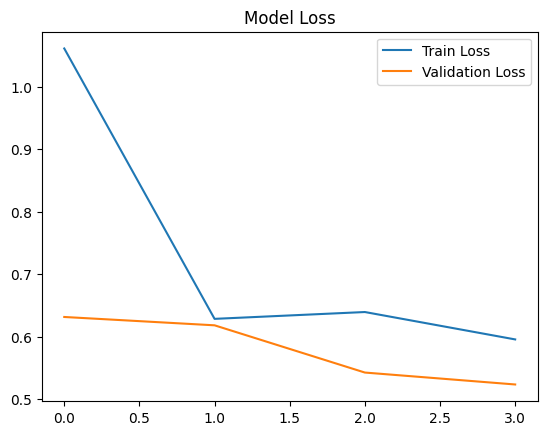

In [16]:
# Accuracy plot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()

# Loss plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Model Loss")
plt.show()

10: Transfer Learning

In [17]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)

output = layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.7113 - loss: 0.5777 - val_accuracy: 0.9118 - val_loss: 0.1870
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.8799 - loss: 0.2553 - val_accuracy: 0.9706 - val_loss: 0.1181
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.9607 - loss: 0.1390 - val_accuracy: 0.9412 - val_loss: 0.0976
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.9654 - loss: 0.1107 - val_accuracy: 0.9412 - val_loss: 0.0807
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.9700 - loss: 0.0789 - val_accuracy: 0.9706 - val_loss: 0.0743


The CNN model successfully classifies images into Fruits and Vegetables.